In [1]:
#!/usr/bin/env python
# coding: utf-8

In[ ]:

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In[5]:

In [3]:
df = pd.read_csv('mechanical.csv')
df.head()

,record_id,rotational_speed_rpm,load_kN,bearing_temperature_c,lubricant_level_pct,vibration_mm_s,condition_class
0,1,850,3.5,38,96,1.1,0
1,2,950,4.2,40,93,1.3,0
2,3,1050,5.0,42,90,1.5,0
3,4,1150,5.8,44,88,1.7,0
4,5,1250,6.5,46,85,2.0,0


In[6]:

Drop record_id column

In [4]:
df = df.drop(columns=['record_id'])

preprocess the data

In [5]:
df = df.dropna()

In [6]:
df.head()

,rotational_speed_rpm,load_kN,bearing_temperature_c,lubricant_level_pct,vibration_mm_s,condition_class
0,850,3.5,38,96,1.1,0
1,950,4.2,40,93,1.3,0
2,1050,5.0,42,90,1.5,0
3,1150,5.8,44,88,1.7,0
4,1250,6.5,46,85,2.0,0


In[7]:

normalize the data

In [7]:
scaler = StandardScaler()
df[['rotational_speed_rpm', 'load_kN', 'bearing_temperature_c', 'lubricant_level_pct', 'vibration_mm_s' ]] = scaler.fit_transform(df[['rotational_speed_rpm', 'load_kN', 'bearing_temperature_c', 'lubricant_level_pct', 'vibration_mm_s']])

In[8]:

split the data into training and testing sets

In [8]:
X = df.drop(columns=['condition_class'])
y = df['condition_class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [9]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (24, 5)
X_test shape: (6, 5)


In[9]:

save the training and testing sets to csv files for later use

In [10]:
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)

In[10]:

load the saved datasets using pd.read_csv('X_train.csv') etc.

In [11]:
X_train_loaded = pd.read_csv('X_train.csv')
X_test_loaded = pd.read_csv('X_test.csv')
y_train_loaded = pd.read_csv('y_train.csv')
y_test_loaded = pd.read_csv('y_test.csv')

In[11]:

check if the loaded datasets are the same as the original datasets

In [12]:
print(
    "X_train matches:",
    np.allclose(
        X_train.reset_index(drop=True).to_numpy(),
        X_train_loaded.to_numpy()
    )
)

X_train matches: True


In [13]:
print(
    "X_test matches:",
    np.allclose(
        X_test.reset_index(drop=True).to_numpy(),
        X_test_loaded.to_numpy()
    )
)

X_test matches: True


In [14]:
print(
    "y_train matches:",
    y_train.reset_index(drop=True).equals(
        y_train_loaded.squeeze("columns")
    )
)

y_train matches: True


In [15]:
print(
    "y_test matches:",
    y_test.reset_index(drop=True).equals(
        y_test_loaded.squeeze("columns")
    )
)

y_test matches: True


In[12]:

build and train a neural network model

In [16]:
tf.random.set_seed(42)

In [17]:
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(3, activation="softmax")
])

In [18]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [19]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

In [20]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=8,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - accuracy: 0.3684 - loss: 0.9475 - val_accuracy: 0.4000 - val_loss: 0.9530
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3684 - loss: 0.9568 - val_accuracy: 0.4000 - val_loss: 0.9339
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5789 - loss: 0.8933 - val_accuracy: 0.4000 - val_loss: 0.9164
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5789 - loss: 0.8750 - val_accuracy: 0.4000 - val_loss: 0.9008
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.5263 - loss: 0.8581 - val_accuracy: 0.4000 - val_loss: 0.8882
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6842 - loss: 0.8512 - val_accuracy: 0.4000 - val_loss: 0.8779
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.6842 - loss: 0.8129 - val_accuracy: 0.4000 - val_loss: 0.8703
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7895 - loss: 0.7862 - val_accuracy: 0.4000 - val_loss

In [21]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

Test loss: 0.6351
Test accuracy: 0.6667


In [22]:
predicted_classes = model.predict(X_test).argmax(axis=1)
print("Predicted classes:", predicted_classes)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
Predicted classes: [2 0 2 2 0 0]


In[13]:

Classification performance plots.<br>
The classifier has three output probabilities and uses categorical loss.

In [23]:
classification_history = history.history

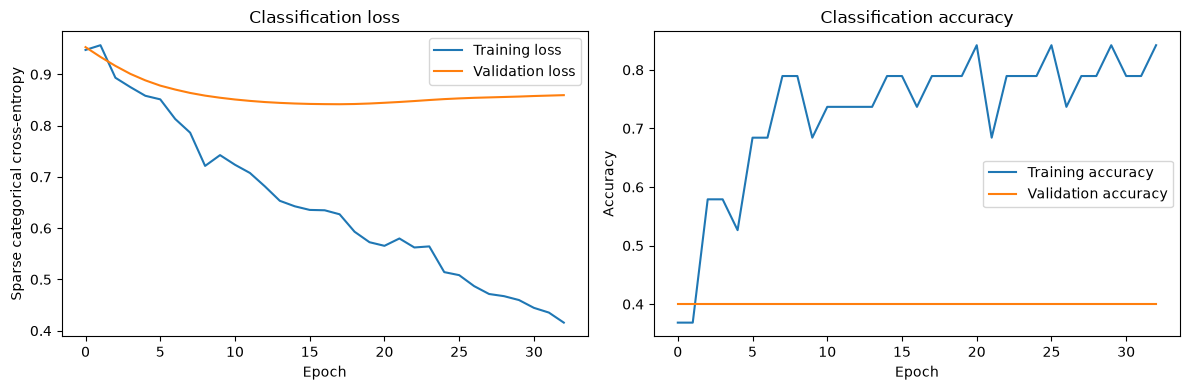

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(classification_history["loss"], label="Training loss")
axes[0].plot(classification_history["val_loss"], label="Validation loss")
axes[0].set_title("Classification loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Sparse categorical cross-entropy")
axes[0].legend()
axes[1].plot(classification_history["accuracy"], label="Training accuracy")
axes[1].plot(classification_history["val_accuracy"], label="Validation accuracy")
axes[1].set_title("Classification accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

In[14]:

REGRESSION MODEL<br>
This section intentionally uses the same condition_class values as a numeric<br>
target. It demonstrates regression, but condition_class is fundamentally a<br>
categorical label, so classification is the better model for the actual task.<br>
Unlike the classifier, this model has one linear output and predicts values<br>
such as 0.2 or 1.8 rather than class probabilities.

In [25]:
tf.random.set_seed(42)

In [26]:
regression_model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="linear")
])

In [27]:
regression_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=[keras.metrics.MeanAbsoluteError(name="mae")]
)

In [28]:
regression_early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

In [29]:
regression_history = regression_model.fit(
    X_train,
    y_train.astype("float32"),
    validation_split=0.2,
    epochs=200,
    batch_size=8,
    callbacks=[regression_early_stopping],
    verbose=1
)

Epoch 1/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 239ms/step - loss: 3.1524 - mae: 1.5476 - val_loss: 0.8086 - val_mae: 0.8195
Epoch 2/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 2.9051 - mae: 1.4521 - val_loss: 0.7489 - val_mae: 0.7749
Epoch 3/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 2.7180 - mae: 1.4036 - val_loss: 0.7010 - val_mae: 0.7347
Epoch 4/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 2.6795 - mae: 1.3990 - val_loss: 0.6588 - val_mae: 0.6960
Epoch 5/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 2.4358 - mae: 1.3012 - val_loss: 0.6264 - val_mae: 0.6631
Epoch 6/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 2.3403 - mae: 1.2587 - val_loss: 0.6016 - val_mae: 0.6344
Epoch 7/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 2.2211 - mae: 1.2113 - val_loss: 0.5811 - val_mae: 0.6088
Epoch 8/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 2.1664 - mae: 1.1844 - val_loss: 0.5645 - val_mae: 0.5908
Epoch 9/200
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 2.1442 - mae:

In [30]:
regression_loss, regression_mae = regression_model.evaluate(
    X_test,
    y_test.astype("float32"),
    verbose=0
)
regression_rmse = np.sqrt(regression_loss)
print(f"Regression test MSE: {regression_loss:.4f}")
print(f"Regression test RMSE: {regression_rmse:.4f}")
print(f"Regression test MAE: {regression_mae:.4f}")

Regression test MSE: 0.0876
Regression test RMSE: 0.2959
Regression test MAE: 0.2583


In [31]:
regression_predictions = regression_model.predict(X_test, verbose=0).ravel()
regression_results = pd.DataFrame({
    "actual_class": y_test.to_numpy(),
    "predicted_numeric_value": regression_predictions,
    "predicted_nearest_class": np.clip(
        np.rint(regression_predictions), 0, 2
    ).astype(int)
})
print(regression_results.head())

   actual_class  predicted_numeric_value  predicted_nearest_class
0             2                 2.271152                        2
1             1                 0.555820                        1
2             2                 1.911970                        2
3             1                 1.327151                        1
4             0                 0.370640                        0


Regression performance plots.

In [32]:
regression_history_data = regression_history.history

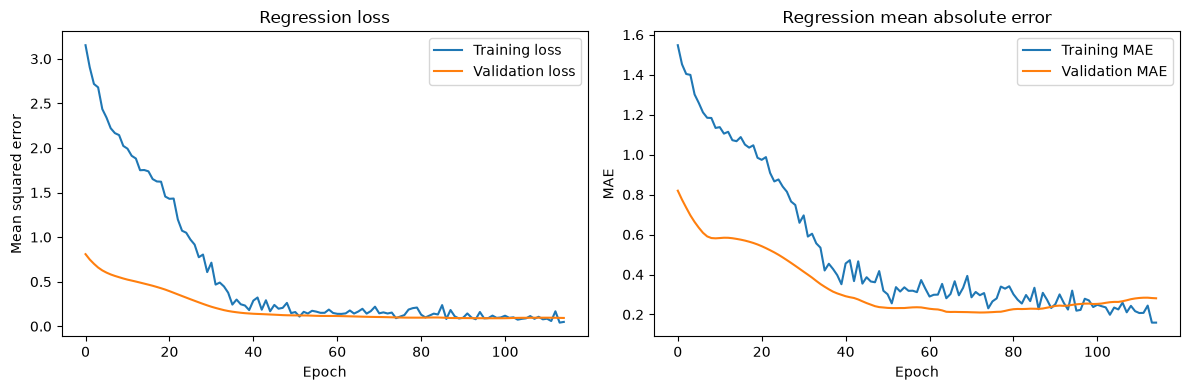

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(regression_history_data["loss"], label="Training loss")
axes[0].plot(regression_history_data["val_loss"], label="Validation loss")
axes[0].set_title("Regression loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Mean squared error")
axes[0].legend()
axes[1].plot(regression_history_data["mae"], label="Training MAE")
axes[1].plot(regression_history_data["val_mae"], label="Validation MAE")
axes[1].set_title("Regression mean absolute error")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()
plt.tight_layout()
plt.show()